In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
from SpaLP.Label_Transfer import CellAnnotator
import torch
import torch.nn as nn
import torch.optim as optim
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import anndata as ad
from tqdm import tqdm
import time

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

### Pre-training data using two slices

In [4]:
adata_batch1=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.077.h5ad')
adata_batch1.var_names_make_unique()
adata_batch1.obs['batch']='MERFISH_-1.077'

adata_batch2=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.078.h5ad')
adata_batch2.var_names_make_unique()
adata_batch2.obs['batch']='MERFISH_-1.078'

In [5]:
adata_list=[adata_batch1,adata_batch2]
adata = ad.concat(adata_list, join="inner")
adata.obs['type']='Pre-training data'

In [6]:
adatas = []
for batch in adata.obs['batch'].unique():
    a = adata[adata.obs['batch'] == batch].copy()
    sc.pp.scale(a)
    adatas.append(a)
adata = ad.concat(adatas, join="inner")
adata.obsm['feat']=adata.X

In [7]:
graphs = []
for batch in adata.obs['batch'].unique():
    a = adata[adata.obs['batch'] == batch].copy()
    graph = prepare_inputs(a, k=16, device=device)
    graphs.append(graph)

all_features = torch.cat([g.features for g in graphs], dim=0)
all_neighbor_idx = []
offset = 0
for g in graphs:
    all_neighbor_idx.append(g.neighbor_idx + offset)
    offset += g.features.shape[0]
all_neighbor_idx = torch.cat(all_neighbor_idx, dim=0)
graph = Graph(all_features, all_neighbor_idx)

In [8]:
in_channels = graph.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
set_seed(7)
epochs = 200
pbar = tqdm(range(epochs), desc="Training",ncols=200)
for epoch in pbar:
    start_time = time.time()
    model.train()
    optimizer.zero_grad()
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    loss = criterion(reconstructed, graph.features)
    loss.backward()
    optimizer.step()
    elapsed = time.time() - start_time
    pbar.set_postfix({"Epoch": epoch,"Loss": f"{loss.item():.4f}"})

Training: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:07<00:00, 28.40it/s, Epoch=199, Loss=0.9217]


In [10]:
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph.features, graph.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

In [11]:
adata.obsm['SpaLP']=embedding

In [12]:
torch.save(model.state_dict(), "/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting2/77+78_pretrian_model.pth")

In [13]:
adata.write_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting2/Pre-training.h5ad',compression='gzip')

### Inference data using one slice

In [14]:
adata1=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/STARmapPLUS/MERFISH_-1.076.h5ad')
adata1.var_names_make_unique()
adata1.obs['type']='Inference data1'

In [15]:
sc.pp.scale(adata1)
adata1.obsm['feat']=adata1.X

In [16]:
graph1 = prepare_inputs(adata1, k=16, device=device)

### zero-shot inference embedding

In [17]:
in_channels = graph1.features.shape[1]
model = SpatialLocalPooling(in_channels, out_channels=32).to(device)
model.load_state_dict(torch.load("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting2/77+78_pretrian_model.pth", map_location="cpu"))
model.eval()
with torch.no_grad():
    reconstructed,embedding = model(graph1.features, graph1.neighbor_idx)
    reconstructed = reconstructed.cpu().numpy()
    embedding=embedding.cpu().numpy()

adata1.obsm['SpaLP']=embedding

### Train the classifier using the pre-training data

In [18]:
Pre_train_adata=sc.read_h5ad('/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting2/Pre-training.h5ad')

In [19]:
annotator = CellAnnotator(device=device)

annotator.train(Pre_train_adata, embed_key='SpaLP', label_key='major_brain_region', epochs=200,batch_size=2048)

Loading data from .obsm['SpaLP'] and .obs['major_brain_region']...
Start training on cuda:0...


Training: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [01:57<00:00,  1.70it/s, Epoch=199, CrossEntropyLoss=0.0476, Best Acc=95.7252]


Calibrating model using Temperature Scaling...
ECE before calibration: 0.0184
Optimal Temperature found: 1.1550
ECE after calibration: 0.0149
Training completed.


### Predict the label and uncertainty of inference data 1

In [20]:
annotator.predict(adata1, embed_key='SpaLP', save_key='predicted_Label')

Predictions saved to adata.obs['predicted_Label']
uncertainty saved to adata.obs['predicted_Label_uncertainty_uncalibrated']
Calibrated uncertainty saved to adata.obs['predicted_Label_uncertainty_calibrated']


AnnData object with n_obs × n_vars = 42854 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'type', 'predicted_Label', 'predicted_Label_uncertainty', 'predicted_Label_uncertainty_calibrated'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_term_id', '

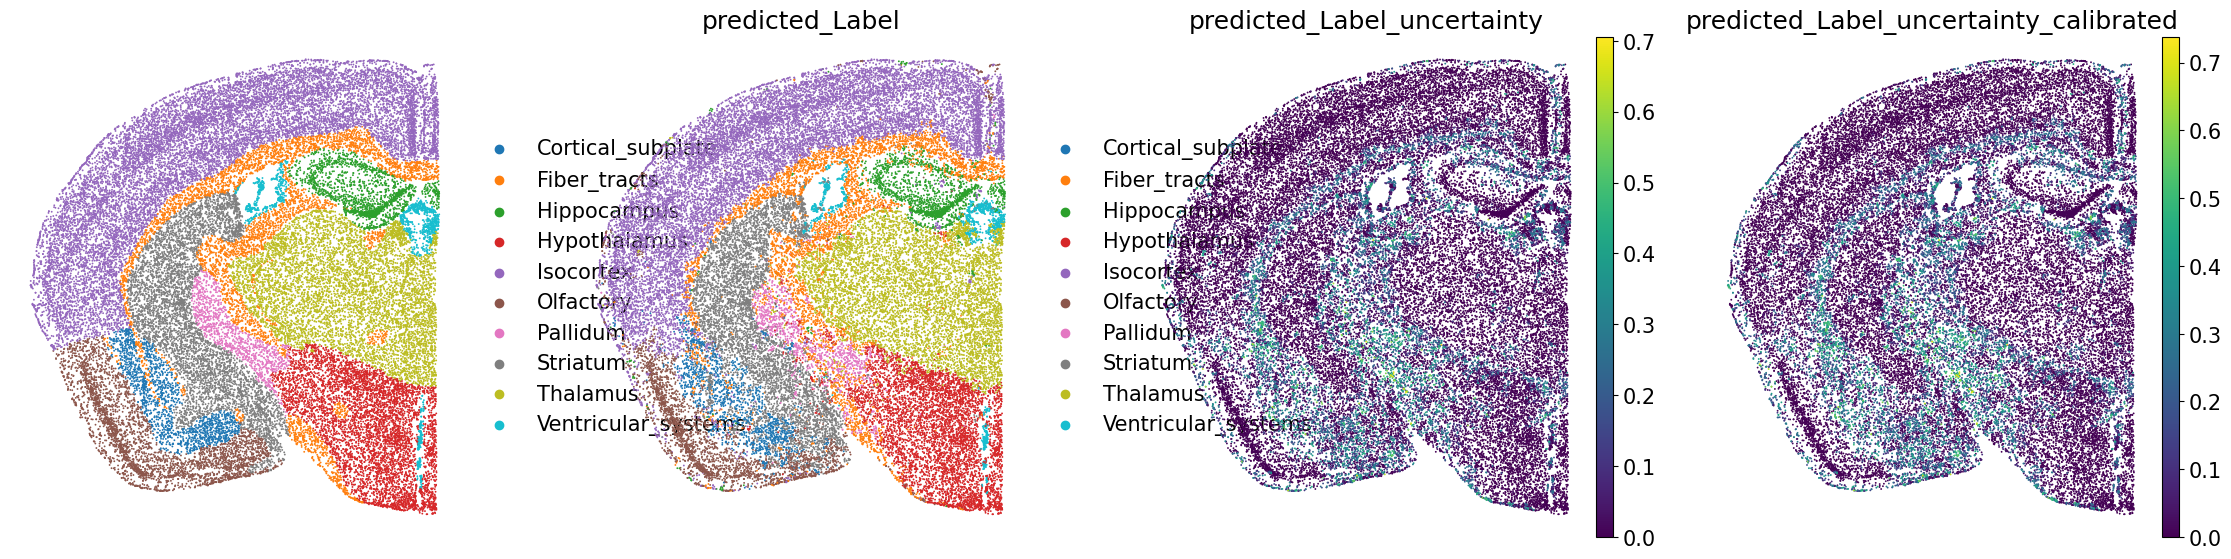

In [21]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,6.5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata1, basis="spatial",s=7,color=['major_brain_region','predicted_Label','predicted_Label_uncertainty','predicted_Label_uncertainty_calibrated'],title='',frameon=False)

In [22]:
import numpy as np
from sklearn.metrics import (homogeneity_score,v_measure_score,adjusted_mutual_info_score,normalized_mutual_info_score,adjusted_rand_score,fowlkes_mallows_score)

true_labels = np.array(adata1.obs['major_brain_region'])
cluster_labels = np.array(adata1.obs['predicted_Label'])

FMI = fowlkes_mallows_score(true_labels, cluster_labels)
homogeneity = homogeneity_score(true_labels, cluster_labels)
v_measure = v_measure_score(true_labels, cluster_labels)
ami = adjusted_mutual_info_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)
ari = adjusted_rand_score(true_labels, cluster_labels)

print("ARI:", ari)
print("NMI:", nmi)
print("AMI:", ami)
print("FMI:", FMI)
print("V-Measure:", v_measure)
print("Homogeneity:", homogeneity)

ARI: 0.7876288953642748
NMI: 0.7023494076719533
AMI: 0.7022100501005686
FMI: 0.822429142430659
V-Measure: 0.7023494076719532
Homogeneity: 0.6987205396766142


### Uncertainty and calibration analysis of mispredictions

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

true_label_col = 'major_brain_region' 
pred_label_col = 'predicted_Label'
uncalib_col = 'predicted_Label_uncertainty' 
calib_col = 'predicted_Label_uncertainty_calibrated'

is_incorrect = adata1.obs[true_label_col] != adata1.obs[pred_label_col]
incorrect_obs = adata1.obs[is_incorrect]

print(f"Total {len(incorrect_obs)} Predicting wrong cells")

uncalib_uncert = incorrect_obs[uncalib_col].values
calib_uncert = incorrect_obs[calib_col].values


mean_uncalib = np.mean(uncalib_uncert)
mean_calib = np.mean(calib_uncert)
print(f"【Predicting wrong cells】Average uncertainty before calibration: {mean_uncalib:.4f}")
print(f"【Predicting wrong cells】Average uncertainty after calibration: {mean_calib:.4f}")

stat, p_value = stats.wilcoxon(uncalib_uncert, calib_uncert)
print(f"p-value: {p_value:.2e}")

Total 6338 Predicting wrong cells
【Predicting wrong cells】Average uncertainty before calibration: 0.1689
【Predicting wrong cells】Average uncertainty after calibration: 0.1921
p-value: 0.00e+00


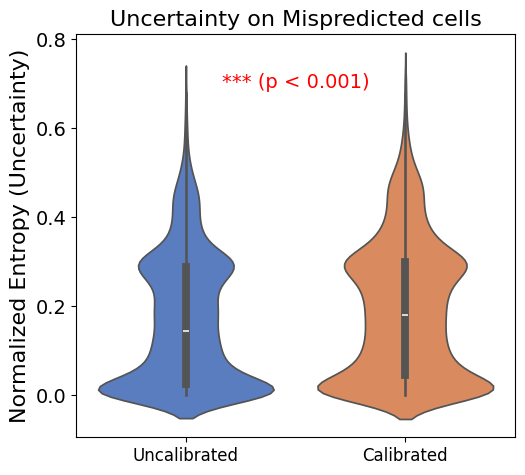

In [26]:
plot_df = pd.DataFrame({
    'Uncertainty': np.concatenate([uncalib_uncert, calib_uncert]),
    'Method': ['Uncalibrated'] * len(uncalib_uncert) + ['Calibrated'] * len(calib_uncert)
})

plt.figure(figsize=(5.5, 5))
sns.violinplot(x='Method', y='Uncertainty', data=plot_df, palette="muted", inner="box")

plt.title('Uncertainty on Mispredicted cells', fontsize=16)
plt.ylabel('Normalized Entropy (Uncertainty)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

if p_value < 0.001:
    plt.text(0.5, plot_df['Uncertainty'].max() * 0.95, '*** (p < 0.001)', ha='center', va='bottom', fontsize=14, color='red')

plt.tight_layout()
plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting2/76mispredicted.png", dpi=600)
plt.show()

In [27]:
is_correct = adata1.obs[true_label_col] == adata1.obs[pred_label_col]
correct_obs = adata1.obs[is_correct]
print(f"Total {len(correct_obs)} Predicting correct cells")
uncalib_uncert_right = correct_obs[uncalib_col].values
calib_uncert_right = correct_obs[calib_col].values

mean_uncalib_right = np.mean(uncalib_uncert_right)
mean_calib_right = np.mean(calib_uncert_right)

print(f"【Predicting right cells】Average uncertainty before calibration: {mean_uncalib_right:.4f}")
print(f"【Predicting right cells】Average uncertainty after calibration: {mean_calib_right:.4f}")
stat_right, p_value_correct = stats.wilcoxon(uncalib_uncert_right, calib_uncert_right)
print(f"right p-value: {p_value_correct:.2e}")

Total 36516 Predicting correct cells
【Predicting right cells】Average uncertainty before calibration: 0.0339
【Predicting right cells】Average uncertainty after calibration: 0.0411
right p-value: 0.00e+00


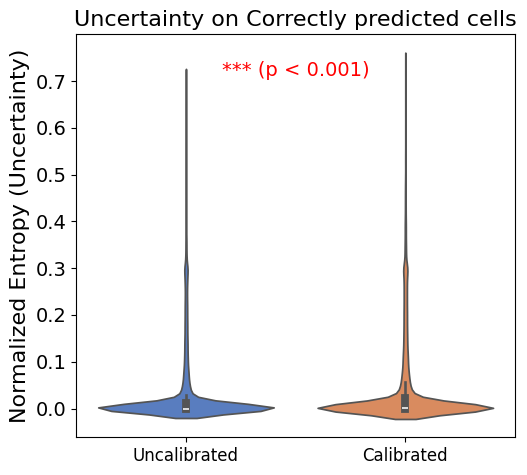

In [28]:
plot_df_correct = pd.DataFrame({
    'Uncertainty': np.concatenate([uncalib_uncert_right, calib_uncert_right]),
    'Method': ['Uncalibrated'] * len(uncalib_uncert_right) + ['Calibrated'] * len(calib_uncert_right)
})

plt.figure(figsize=(5.5, 5))
sns.violinplot(x='Method', y='Uncertainty', data=plot_df_correct, palette="muted", inner="box")
plt.title('Uncertainty on Correctly predicted cells', fontsize=16)
plt.ylabel('Normalized Entropy (Uncertainty)', fontsize=16)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)

if p_value_correct < 0.001:
    plt.text(0.5, plot_df_correct['Uncertainty'].max() * 0.95, '*** (p < 0.001)', 
             ha='center', va='bottom', fontsize=14, color='red')
else:
    plt.text(0.5, plot_df_correct['Uncertainty'].max() * 0.95, f'ns (p = {p_value_correct:.2f})', 
             ha='center', va='bottom', fontsize=14, color='black')

plt.tight_layout()
plt.savefig("/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting2/76correct predicted.png", dpi=600)
plt.show()

In [29]:
sc.settings.figdir = '/home/dbj/SpaLP/gittest/SpaLP/general/MERFISH/setting2/'
sc.settings.set_figure_params(dpi_save=150)

In [33]:
adata1

AnnData object with n_obs × n_vars = 42854 × 1122
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'slice', 'type', 'predicted_Label', 'predicted_Label_uncertainty', 'predicted_Label_uncertainty_calibrated'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'mean', 'std'
    uns: 'citation', 'major_brain_region_colors', 'organism', 'organism_ontology_term_id', '

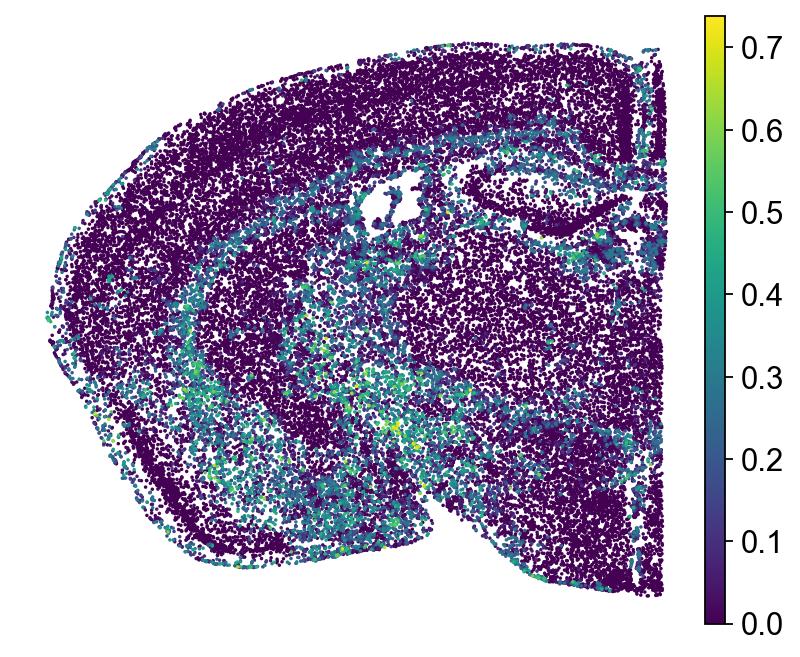

In [35]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (6,5)
plt.rcParams['font.size'] = 15
sc.pl.embedding(adata1,color='predicted_Label_uncertainty_calibrated',basis='spatial',s=10,title='',frameon=False,save='76prectuncertainty_calibrated.png')#,save='pre_train.png')